# Exploratory Data Analysis (EDA) – Retail Transactions

## Objective
The goal of this notebook is to understand the dataset, fix data quality issues,
standardize missing values (NaN), correct data types, and prepare a clean dataset
for future analysis. No rows are dropped in this stage.


### 2️ Import Libraries

In [1]:
import pandas as pd
import numpy as np


In [2]:
!pip install pandas

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('dirty_cafe_sales.csv')

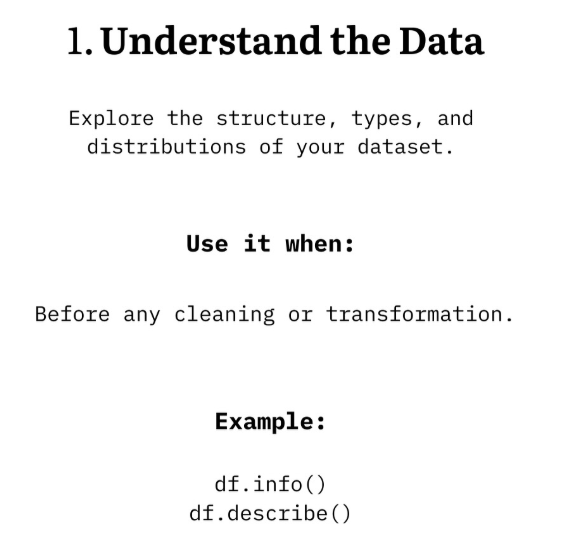


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


import numpy as np

# 1) keep a raw backup BEFORE any modification
df['Location_raw'] = df['Location'].copy()

# 2) create a cleaned, normalized Series to test against
s = df['Location'].astype(str).str.strip().str.lower()

# 3) list of placeholder tokens we treat as missing
bad = {'', 'error', 'unknown', 'na', 'n/a', 'none', 'null', 'blank'}

# 4) boolean mask: True where the value is one of the bad tokens
mask = s.isin(bad)

# 5) assign np.nan to those rows (use .loc to avoid SettingWithCopy issues)
df.loc[mask, 'Location'] = np.nan

# 6) add an explicit missingness indicator column (0 = present, 1 = missing)
df['Location_missing'] = df['Location'].isna().astype(int)

# 7) verification: counts after standardization
print("Missing count:", df['Location'].isna().sum())
print(df['Location'].value_counts(dropna=False))


# Location

In [6]:
df['location_raw']= df['Location'].copy() # first step always make a copy of orginal column or a file  should never perform on og data

In [7]:
s=df['Location'].astype(str).str.strip().str.lower()

In [8]:
bad = {'', 'error', 'unknown', 'na', 'n/a', 'none', 'null', 'blank'} #set{}

In [9]:
mask = s.isin(bad) # this line says if any elements which are present inside bad are present s then they r true othrws false

In [10]:
df.loc[mask,'Location']=np.nan # replace all the values which are true in mask 

In [11]:
df['location_missing']=df['Location'].isna().astype(int)# creating a binary indicator column which will hold values in int 1 for true and 0 for false bec computer understannd binnary lang

In [12]:
print("Missing count:", df['Location'].isna().sum())
print(df['Location'].value_counts(dropna=False))

Missing count: 3961
Location
NaN         3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64


# ITEM

In [13]:
df['Item_raw']= df['Item'].copy() # first copy 

In [14]:
# a = df['Item'].astype(str).str.lower().str.strip() #standrdize 

In [15]:
a = df['Item'].astype(str).str.strip().str.lower()

In [16]:
# 3) list of placeholder tokens we treat as missing
bad = {'', 'error', 'unknown', 'na', 'n/a', 'none', 'null', 'blank'}

In [17]:
mask_1 = a.isin(bad) # convert all the elements into true for all the elements  that  are present in bad as a 

In [18]:
df.loc[mask_1,'Item']= np.nan # ths line of code says that all th 

In [19]:
df['Item_missing']=df['Item'].isna().astype(int) # created a binary column 

In [20]:
# 7) verification: counts after standardization
print("Missing count:", df['Item'].isna().sum())
print(df['Item'].value_counts(dropna=False))

Missing count: 969
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
NaN          969
Name: count, dtype: int64


In [21]:
df['Payment Method_raw'] = df['Payment Method'].copy() # raw copy to save original data 
b=df['Payment Method'].astype(str).str.strip().str.lower() #normalization used for finding garbage 
mask_2 = b.isin(bad) # mask selects rows,
df.loc[mask_2,'Payment Method']=np.nan #NaN standardizes missingness
df['Payment Method_missing']= df['Payment Method'].isna().astype(int)
print('Missing values:',df['Payment Method'].isna().sum())
print(df['Payment Method'].value_counts(dropna=False))

Missing values: 3178
Payment Method
NaN               3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Transaction ID          10000 non-null  str  
 1   Item                    9031 non-null   str  
 2   Quantity                9862 non-null   str  
 3   Price Per Unit          9821 non-null   str  
 4   Total Spent             9827 non-null   str  
 5   Payment Method          6822 non-null   str  
 6   Location                6039 non-null   str  
 7   Transaction Date        9841 non-null   str  
 8   location_raw            6735 non-null   str  
 9   location_missing        10000 non-null  int64
 10  Item_raw                9667 non-null   str  
 11  Item_missing            10000 non-null  int64
 12  Payment Method_raw      7421 non-null   str  
 13  Payment Method_missing  10000 non-null  int64
dtypes: int64(3), str(11)
memory usage: 1.1 MB


In [23]:
df['Quantity_raw'] = df['Quantity'].copy
df['price_per_unit_raw'] = df['Price Per Unit'].copy
df['Total_spent_raw'] = df['Total Spent'].copy

In [24]:
# backup original date
df['Transaction_Date_raw'] = df['Transaction Date'].copy()

# convert to datetime
df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date'],
    errors='coerce'
)


#### What this does (simple)

Valid dates → proper datetime

Invalid dates → NaT (date version of NaN)

No guessing

In [25]:
df['Transaction Date'].info()


<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Transaction Date
Non-Null Count  Dtype         
--------------  -----         
9540 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 78.3 KB


In [26]:
df['Transaction Date'].isna().sum()

np.int64(460)

# converting str columns to numeric and appling coerce to convert all non numeric rows to nan

In [27]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'],errors = 'coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'],errors = 'coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'],errors = 'coerce')


In [28]:
df[['Quantity','Total Spent','Price Per Unit']].info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Quantity        9521 non-null   float64
 1   Total Spent     9498 non-null   float64
 2   Price Per Unit  9467 non-null   float64
dtypes: float64(3)
memory usage: 234.5 KB


In [29]:
expected_total = df['Quantity']*df['Price Per Unit']

In [30]:
inconsistent_mask = (
    df['Total Spent'].notna() &
    expected_total.notna() & 
    (df['Total Spent'] != expected_total)
)

In [31]:
df.loc[inconsistent_mask, ['Quantity','Price Per Unit', 'Total Spent']].head()

,Quantity,Price Per Unit,Total Spent


In [32]:
recompute_mask = (
    df['Total Spent'].isna() &
    df['Quantity'].notna() &
    df['Price Per Unit'].notna()
)

df.loc[recompute_mask, 'Total Spent'] = expected_total


In [33]:
df['Total_mismatch'] = inconsistent_mask.astype(int)


In [34]:
df[['Quantity','Price Per Unit','Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9960.000000
mean,3.028463,2.949984,8.930924
std,1.419007,1.278450,6.004475
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [35]:
expected_total = df['Quantity'] * df['Price Per Unit']


In [36]:
print(recompute_mask)

0       False
1       False
2        True
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [37]:
recompute_mask = (
    df['Total Spent'].isna() &
    df['Quantity'].notna() &
    df['Price Per Unit'].notna()
)


In [38]:
df.loc[recompute_mask,
       ['Quantity','Price Per Unit','Total Spent']].head()


,Quantity,Price Per Unit,Total Spent


In [39]:
recompute_mask.sum()


np.int64(0)

In [40]:
(
    df['Quantity'].notna() &
    df['Price Per Unit'].notna() &
    df['Total Spent'].isna()
).sum()


np.int64(0)

In [41]:
df.isna().sum()


Transaction ID               0
Item                       969
Quantity                   479
Price Per Unit             533
Total Spent                 40
Payment Method            3178
Location                  3961
Transaction Date           460
location_raw              3265
location_missing             0
Item_raw                   333
Item_missing                 0
Payment Method_raw        2579
Payment Method_missing       0
Quantity_raw                 0
price_per_unit_raw           0
Total_spent_raw              0
Transaction_Date_raw       159
Total_mismatch               0
dtype: int64

In [42]:
df.dtypes


Transaction ID                       str
Item                                 str
Quantity                         float64
Price Per Unit                   float64
Total Spent                      float64
Payment Method                       str
Location                             str
Transaction Date          datetime64[us]
location_raw                         str
location_missing                   int64
Item_raw                             str
Item_missing                       int64
Payment Method_raw                   str
Payment Method_missing             int64
Quantity_raw                      object
price_per_unit_raw                object
Total_spent_raw                   object
Transaction_Date_raw                 str
Total_mismatch                     int64
dtype: object

In [43]:
(df['Quantity'] * df['Price Per Unit'] == df['Total Spent']).value_counts(dropna=False)


True     9006
False     994
Name: count, dtype: int64

In [44]:
raw_cols = [
    'Transaction ID',
    'Item_raw',
    'Quantity_raw',
    'price_per_unit_raw',
    'Total_spent_raw',
    'Payment Method_raw',
    'location_raw',
    'Transaction Date'
]

df_raw = df[raw_cols].copy()
df_raw.to_csv('transactions_raw.csv', index=False)


In [45]:
df_clean = df.copy()
df_clean.to_csv('dirty_cafe_clean.csv', index=False)


In [46]:
pd.read_csv('transactions_raw.csv').shape



(10000, 8)

In [47]:
pd.read_csv('dirty_cafe_clean.csv').shape

(10000, 19)

### Creating dashboard-ready dataset

In [48]:
dashboard_cols = [
    'Transaction ID',
    'Item',
    'Quantity',
    'Price Per Unit',
    'Total Spent',
    'Payment Method',
    'Location',
    'Transaction Date'
]

df_dashboard = df[dashboard_cols].copy()


### Drop rows ONLY needed for dashboard

In [49]:
df_dashboard = df_dashboard.dropna(
    subset=['Item', 'Total Spent']
)


In [51]:
df_dashboard = df_dashboard.dropna(
    subset=['Payment Method', 'Location', 'Transaction Date']
)


### Now:

All charts will be clean

No confusing gaps

No misleading visuals

###  Final check before saving

In [52]:
df_dashboard.info()


<class 'pandas.DataFrame'>
Index: 3560 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    3560 non-null   str           
 1   Item              3560 non-null   str           
 2   Quantity          3411 non-null   float64       
 3   Price Per Unit    3379 non-null   float64       
 4   Total Spent       3560 non-null   float64       
 5   Payment Method    3560 non-null   str           
 6   Location          3560 non-null   str           
 7   Transaction Date  3560 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 250.3 KB


In [ ]:
df_dashboard.to_csv('../data/cafe_sales_dashboard.csv', index=False)
